In [1]:
from torch.utils.data import DataLoader, random_split
import segmentation_models_pytorch as smp
import os
import sys


sys.path.append(os.path.abspath(os.path.join('..', '..')))

from carvana.config import *
from carvana.dataset.dataset import CarvanaHRDataset
from carvana.dataset.transforms import get_hr_transforms
from carvana.train.losses import BCELoss, DiceLoss, BCEDiceLoss
from carvana.train.trainer_hq import run_training_hq
from carvana.train.utils import *

/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
STAGE1_OUTPUTS = os.path.abspath(os.path.join('..', 'outputs'))
HQ_SAVE_DIR = '../outputs_hr'
os.makedirs(HQ_SAVE_DIR, exist_ok=True)

In [3]:
HR_BATCH_SIZE = 4
ACCUMULATION_STEPS = 4
HR_LEARNING_RATE = 1e-5

In [4]:
train_hr_transform = get_hr_transforms(crop_size=512, is_train=True)
val_hr_transform = get_hr_transforms(crop_size=512, is_train=False)

In [5]:
full_hr_dataset = CarvanaHRDataset(
    images_dir=TRAIN_IMAGES_DIR,
    masks_dir=TRAIN_MASKS_DIR,
    normalize_mask=True
)

In [6]:
train_size = int(0.8 * len(full_hr_dataset))
val_size = len(full_hr_dataset) - train_size
train_subset, val_subset = random_split(full_hr_dataset, [train_size, val_size])

In [7]:
train_subset.dataset.transform = train_hr_transform
val_subset.dataset.transform = val_hr_transform

In [8]:
train_loader = DataLoader(train_subset, batch_size=HR_BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=HR_BATCH_SIZE, shuffle=False, num_workers=4)

In [9]:
models_to_finetune = [
    {'name': 'BCE', 'file': 'best_model_BCEWithLogitsLoss.pth', 'loss': BCELoss},
    {'name': 'Dice', 'file': 'best_model_DiceLoss.pth', 'loss': DiceLoss()},
    {'name': 'BCEDice', 'file': 'best_model_BCEDiceLoss.pth', 'loss': BCEDiceLoss()},
]

In [10]:
all_hq_results = {}
final_trained_models = {}

FINE-TUNING ДЛЯ: BCE
[+] Веса BCE загружены


Training: 100%|██████████| 1018/1018 [15:10<00:00,  1.12it/s, iou=0.758, loss=0.377]


[*] Лучшая модель сохранена (IoU: 0.7261)
Epoch 01 | Val Loss: 0.3982 | Val IoU: 0.7261 | Val Dice: 0.8285


Training: 100%|██████████| 1018/1018 [14:46<00:00,  1.15it/s, iou=0.92, loss=0.204] 


[*] Лучшая модель сохранена (IoU: 0.8624)
Epoch 02 | Val Loss: 0.2507 | Val IoU: 0.8624 | Val Dice: 0.9189


...

[*] Лучшая модель сохранена (IoU: 0.9513)
Epoch 03 | Val Loss: 0.1991 | Val IoU: 0.9513 | Val Dice: 0.9745


Training: 100%|██████████| 1018/1018 [08:26<00:00,  2.01it/s, iou=0.988, loss=0.0805]


[*] Лучшая модель сохранена (IoU: 0.9835)
Epoch 04 | Val Loss: 0.1611 | Val IoU: 0.9835 | Val Dice: 0.9917


Training: 100%|██████████| 1018/1018 [08:34<00:00,  1.98it/s, iou=0.988, loss=0.142] 


[*] Лучшая модель сохранена (IoU: 0.9866)
[EarlyStopping] Счетчик: 1 из 1
Ранняя остановка на 05 эпохе


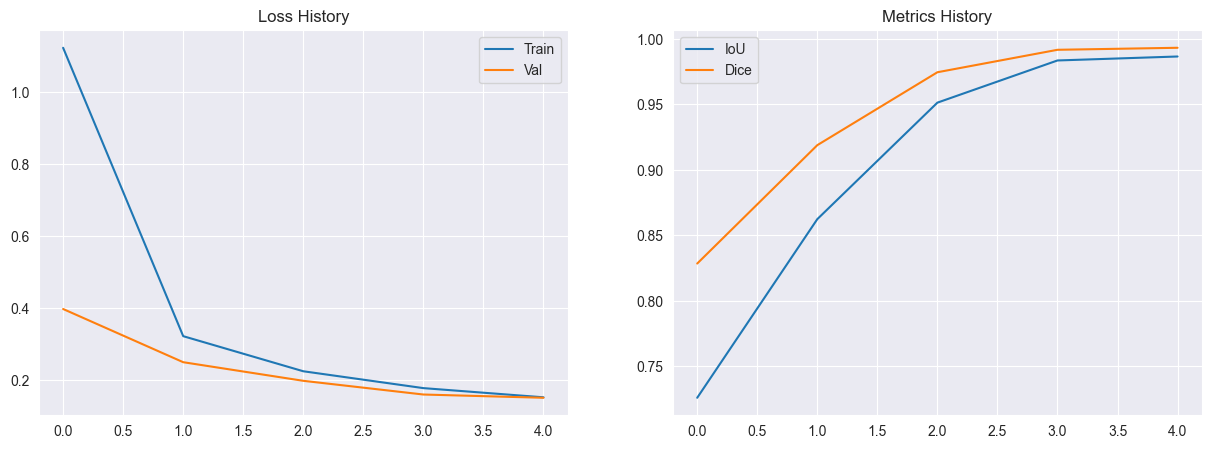

FINE-TUNING ДЛЯ: Dice
[+] Веса Dice загружены


Training: 100%|██████████| 1018/1018 [08:34<00:00,  1.98it/s, iou=0.931, loss=0.0849]


[*] Лучшая модель сохранена (IoU: 0.9069)
Epoch 01 | Val Loss: 0.0936 | Val IoU: 0.9069 | Val Dice: 0.9505


Training: 100%|██████████| 1018/1018 [08:37<00:00,  1.97it/s, iou=0.972, loss=0.0451]


[*] Лучшая модель сохранена (IoU: 0.9841)
Epoch 02 | Val Loss: 0.0411 | Val IoU: 0.9841 | Val Dice: 0.9919


Training: 100%|██████████| 1018/1018 [09:09<00:00,  1.85it/s, iou=0.974, loss=0.0566]


[*] Лучшая модель сохранена (IoU: 0.9897)
[EarlyStopping] Счетчик: 1 из 1
Ранняя остановка на 03 эпохе


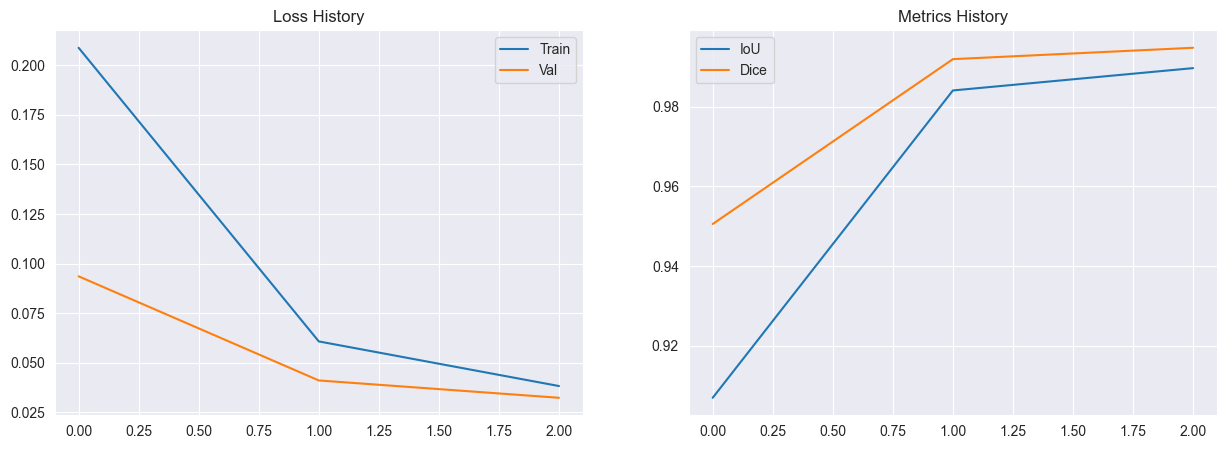

FINE-TUNING ДЛЯ: BCEDice
[+] Веса BCEDice загружены


Training: 100%|██████████| 1018/1018 [09:00<00:00,  1.88it/s, iou=0.777, loss=0.386]


[*] Лучшая модель сохранена (IoU: 0.8254)
Epoch 01 | Val Loss: 0.2882 | Val IoU: 0.8254 | Val Dice: 0.8938


Training: 100%|██████████| 1018/1018 [09:02<00:00,  1.88it/s, iou=0.96, loss=0.184]  


[*] Лучшая модель сохранена (IoU: 0.9739)
Epoch 02 | Val Loss: 0.1393 | Val IoU: 0.9739 | Val Dice: 0.9864


...

[*] Лучшая модель сохранена (IoU: 0.9892)
Epoch 04 | Val Loss: 0.0976 | Val IoU: 0.9892 | Val Dice: 0.9946


Training: 100%|██████████| 1018/1018 [09:07<00:00,  1.86it/s, iou=0.985, loss=0.113] 


[*] Лучшая модель сохранена (IoU: 0.9917)
Epoch 05 | Val Loss: 0.0855 | Val IoU: 0.9917 | Val Dice: 0.9958


Training: 100%|██████████| 1018/1018 [09:46<00:00,  1.74it/s, iou=0.989, loss=0.0987] 


[*] Лучшая модель сохранена (IoU: 0.9925)
[EarlyStopping] Счетчик: 1 из 1
Ранняя остановка на 06 эпохе


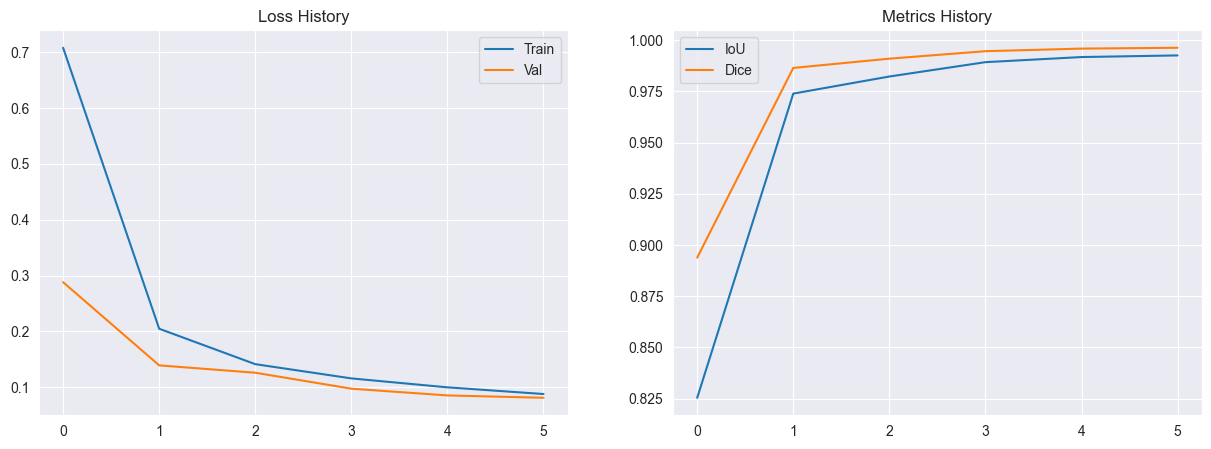

In [16]:
for m_info in models_to_finetune:
    print(f"FINE-TUNING ДЛЯ: {m_info['name']}")

    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=1
    ).to(DEVICE)

    weights_path = os.path.join(STAGE1_OUTPUTS, m_info['file'])
    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
        print(f"[+] Веса {m_info['name']} загружены")
    else:
        print(f"[!] Пропуск {m_info['name']}: файл {weights_path} не найден")
        continue

    optimizer = torch.optim.AdamW(model.parameters(), lr=HR_LEARNING_RATE)

    history = run_training_hq(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=m_info['loss'],
        device=DEVICE,
        epochs=8,
        accum_steps=ACCUMULATION_STEPS,
        patience=1,
        save_dir=HQ_SAVE_DIR,
        model_name=f"HQ_{m_info['name']}"
    )

    all_hq_results[f"HQ_{m_info['name']}"] = history
    final_trained_models[f"HQ_{m_info['name']}"] = model

In [12]:
comparison_table = get_best_metrics_table(all_hq_results)

In [13]:
display(comparison_table.style.highlight_max(subset=['Best Val IoU', 'Best Val Dice'], color='green'))

,index,Loss Function,Best Val IoU,Best Val Dice,Loss at Best IoU,Epochs Trained,Best Epoch
0,2,HQ_BCEDice,0.992500,0.996228,0.081310,6,6
1,1,HQ_Dice,0.989690,0.994803,0.032321,3,3
2,0,HQ_BCE,0.986564,0.993219,0.152068,5,5


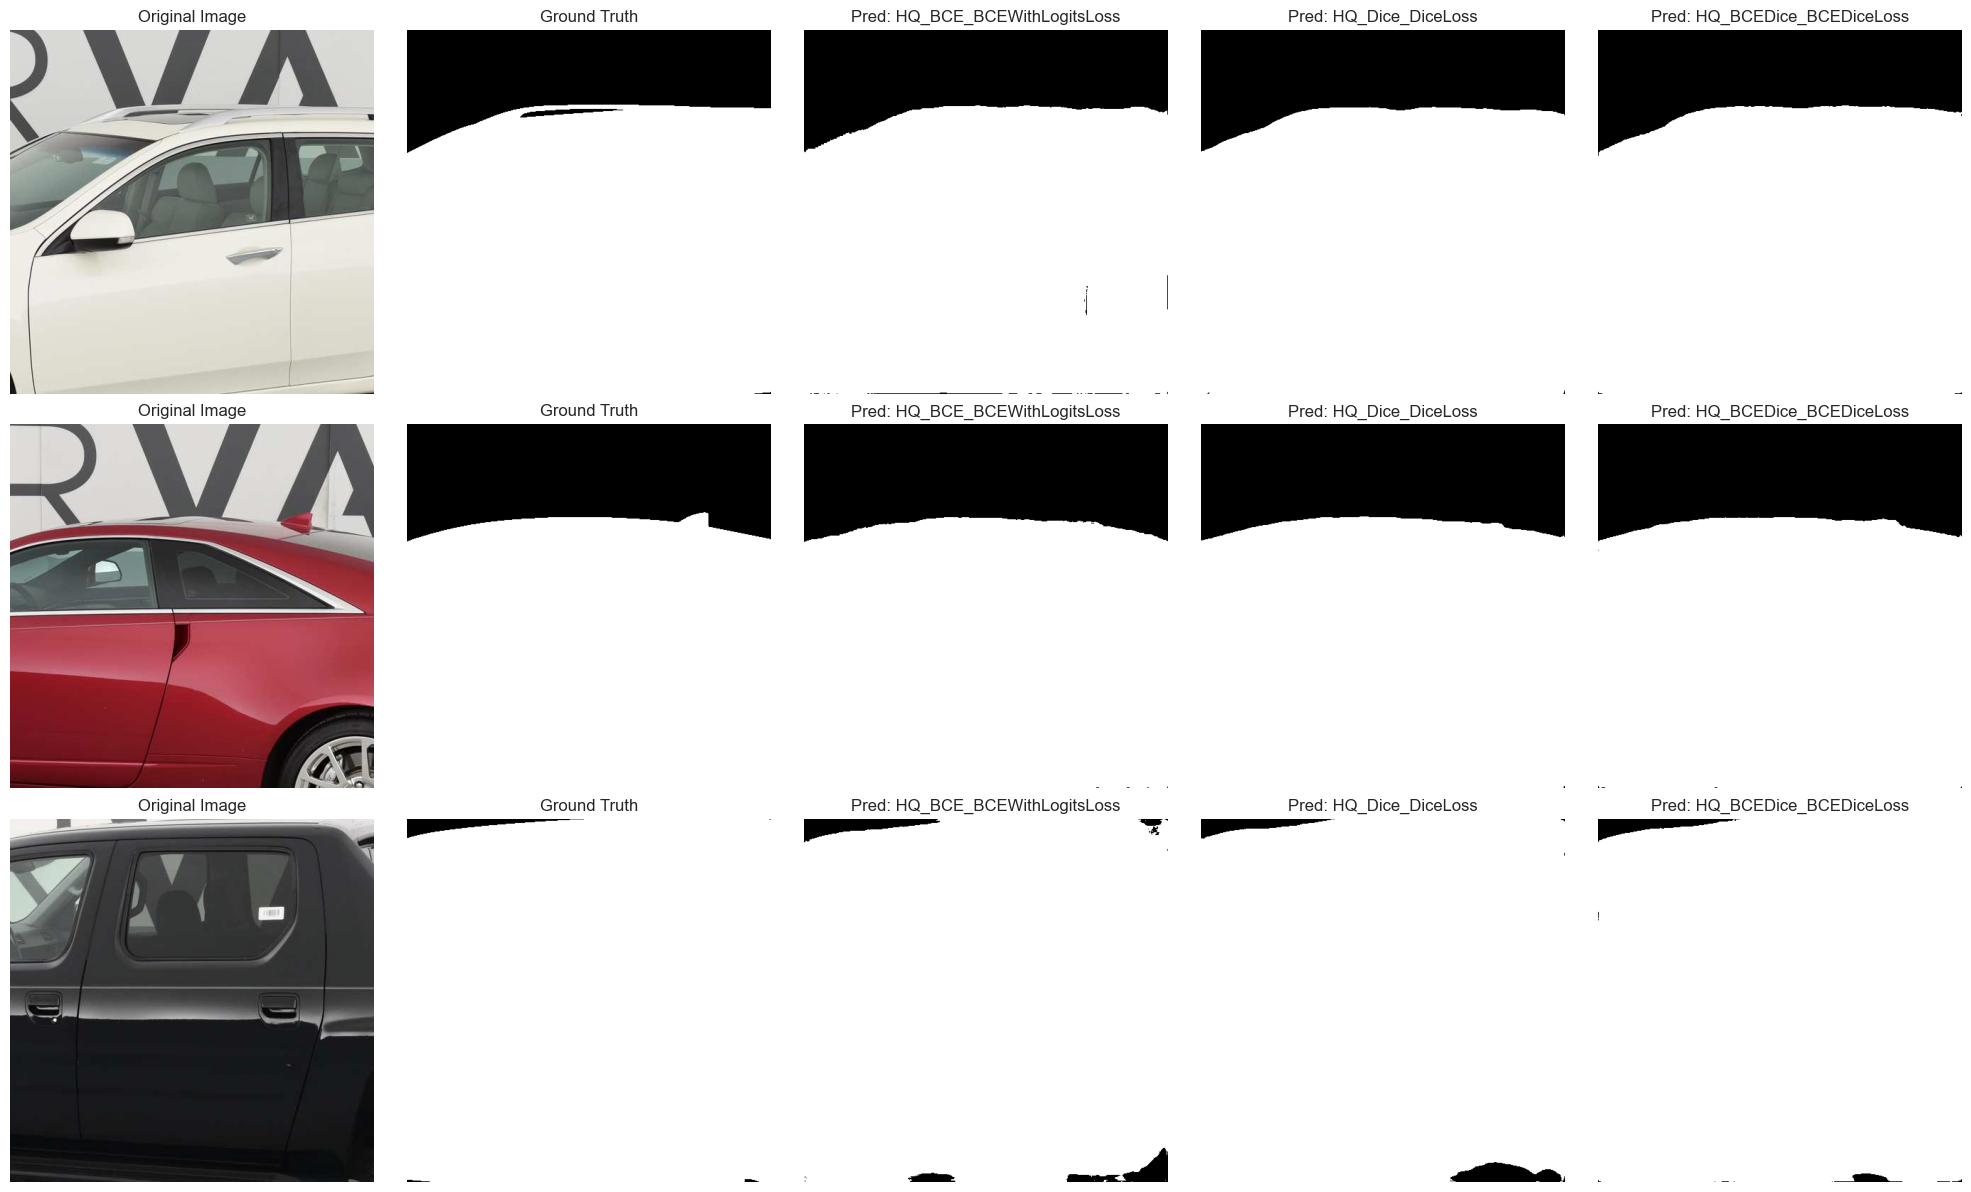

In [18]:
visualize_model_comparison(final_trained_models, val_subset, DEVICE)

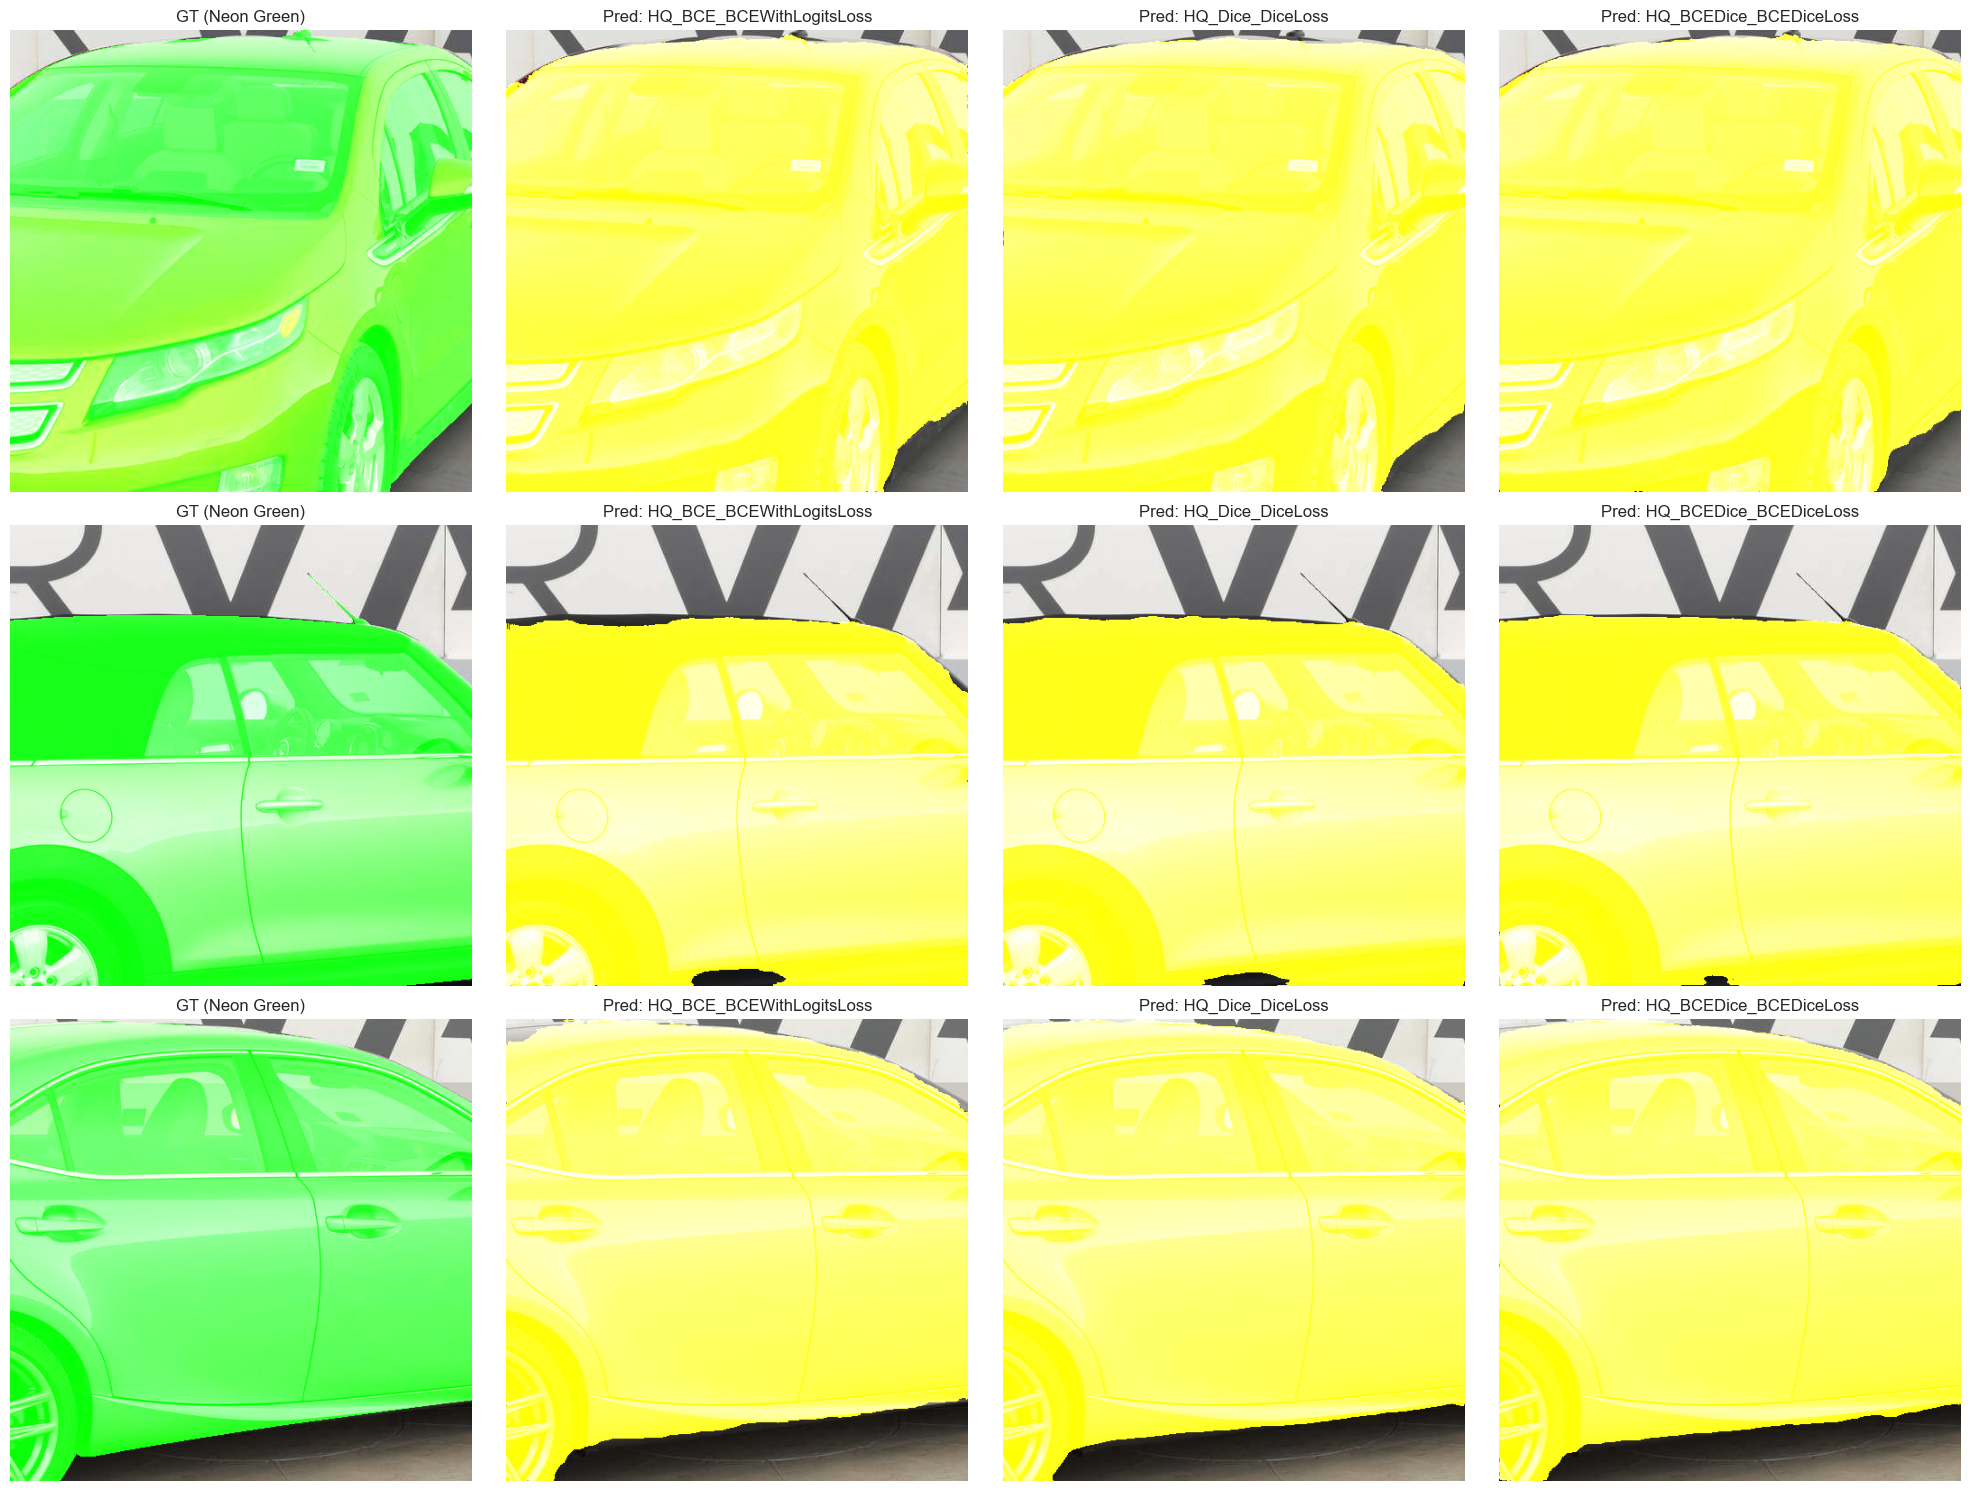

In [19]:
show_results(final_trained_models, val_subset, DEVICE)